In [39]:
import numpy as np
import psfsim
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.interpolate as sp_itp

from psfsim.polychrom import PolychromaticPSF

In [40]:
j129 = np.linspace( 1.131, 1.454, 10 ) # microns

# PSF generation and downsampling parameters
ps_size = 96
ovsamp = pixel_size = 8
mag = 1e8 # some unit

# Poisson resampling and spike fitting parameters
step = 0.1 # degrees
borders = ( 0.2, 1. )
bound = ps_size // 2
center = np.array( ( ps_size // 2, ps_size // 2 ) )
flux_factor = pixel_size**2 * mag

# Interpolation parameters
dense_ps_size = 600
dense_bound = dense_ps_size // 2
dense_center = np.array( ( dense_ps_size // 2, dense_ps_size // 2 ) )

In [ ]:
def line_coords( angle, bound, center=np.array( ( 0, 0 ) ) ):
    # since (0, 0) in data coords is top left instead of bottom left we must use clockwise rotations to get
    # a visually ccl rotation. However we will take a transpose later anyways so the rotation matrix def is ccl, as expected. How quaint
    angle = np.deg2rad( angle )
    # print( angle )
    line = np.zeros( ( 2, bound ) )
    line[0] = np.arange( bound )

    rotation = np.array( (
        ( np.cos( angle ), -np.sin( angle ) ),
        ( np.sin( angle ), np.cos( angle ) ),
    ) )

    if len( rotation.shape ) > 2:
        line = line.reshape( ( 1, 2, bound ) )

    # print( line.shape )
    # print( rotation.T.shape )
    
    return np.int32( rotation.T @ line ) + np.int32( np.reshape( center, ( 2, 1 ) ) )

def find_spikes( image, step, bound=1024, center=np.array( ( 0, 0 )  ), borders=( 0., 1. ), threshold=0.5, verbose=False ):
    angles = np.linspace( 0, 360, num=np.int32( 360. / step ), endpoint=False )

    lines = line_coords( angles, bound, center )
    image_analyze = image.T # imshow will display the image as row,col with 0,0 in top left. For our analysis we want (col,row).
    
    line_vals = image_analyze[ lines[:,0], lines[:,1] ]
    sums = np.sum( line_vals, axis=-1 )

    # 0 to 1 for these. Should I add a way to make it force 0 <= borders[0] < borders[1] <= 1?
    range_low = np.int_( borders[0] * bound )
    range_high = np.int_( borders[1] * bound )

    sums = np.sum( line_vals[:, range_low:range_high ], axis=-1 )    
    '''
    This formula is slightly different from the midpoint formula from before. The formula defaults to 50%, using 50% recovers the original behavior. Other
    ways to do this include rejecting the lowest 10% of values or so. That one might be worth pursuing in the future. The goal is to keep this method as simple as possible--
    I do NOT want to start staring at noise to find spikes.

    There is another method that may be worth pursuing that involves a boxcar average that goes around the circle and might be able to correct for groups of spikes that are much
    higher or lower than the naive cutoff assumes.
    '''
    diff = np.max( sums ) - np.min( sums )
    cutoff = np.min( sums ) + ( diff * threshold )
    spike_indices = np.where( sums > cutoff )[0]
    spike_angles = angles[ spike_indices ]
    # print( np.diff( spike_angles ) )

    # try 3 degrees to tell differing spikes apart for now
    spike_angle_discriminator = 3.
    borders = np.where( np.diff( spike_angles ) > spike_angle_discriminator )[0]
    spike_groups = np.split( spike_angles, borders + 1 )
    spike_group_indices = np.split( spike_indices, borders + 1 )

    print( f'Cutoff of {cutoff:.3f}' )
    # unfortunately this for loop is necessary unless theres a convenient package for jagged arrays
    spike_list = np.zeros( len( spike_groups ) )
    for i in np.arange( len( spike_groups ) ):

        idx_min_r = spike_group_indices[i][0]
        idx_max_l = spike_group_indices[i][-1]

        idx_min_l = idx_min_r - 1
        idx_max_r = idx_max_l + 1

        slope_left = ( sums[ idx_min_r ] - sums[ idx_min_l ] ) / step
        slope_right = ( sums[ idx_max_r ] - sums[ idx_max_l ] ) / step

        th_min = ( ( cutoff - sums[ idx_min_l ] ) / slope_left ) + angles[ idx_min_l ]
        th_max = ( ( cutoff - sums[ idx_max_l ] ) / slope_right ) + angles[ idx_max_l ]

        # print( f'{sums[idx_min_l]:.3f}, {sums[idx_min_r]:.3f} and {sums[idx_max_l]:.3f}, {sums[idx_max_r]:.3f}' )
        print( f'{angles[idx_min_l]:.2f}, {angles[idx_min_r]:.2f} and {angles[idx_max_l]:.2f}, {angles[idx_max_r]:.2f}. interpolated as {th_min:.2f}, {th_max:.2f}' )

        # spike_list[i] = np.median( spike_groups[i] )
        spike_list[i] = ( th_min + th_max ) / 2.

    # print( spike_list )
    if verbose:
        return sums, spike_angles, cutoff, spike_list
    else:
        return spike_list

def draw_ray( ax, angle, bound, center=np.array( ( 0, 0 ) ), borders=( 0., 1. ), **kwargs ):
    line = line_coords( angle, bound, center )
    range_low = np.int_( borders[0] * bound )
    range_high = np.int_( borders[1] * bound )
    ax.plot( line[ 0, range_low:range_high ], line[ 1, range_low:range_high ], **kwargs )
    return

def downsample_2d_image( image, pixel_size=8 ): # ONLY WORKS ON 2D IMAGES
    subpixel_side = np.arange( pixel_size )
    subpixel_cols, subpixel_rows = np.meshgrid( subpixel_side, subpixel_side )

    dsamp_size = image.shape[0] // pixel_size
    pixels_side = np.arange( dsamp_size ) * pixel_size
    pixels_cols, pixels_rows = np.meshgrid( pixels_side, pixels_side )
    
    pixels_rows = pixels_rows[ :, :, np.newaxis ] # promote to 3D
    pixels_cols = pixels_cols[ :, :, np.newaxis ]
    
    idx_arr_subpixel_rows = np.full( ( dsamp_size, dsamp_size, pixel_size**2 ), subpixel_rows.flatten( ) )
    idx_arr_subpixel_cols = np.full( ( dsamp_size, dsamp_size, pixel_size**2 ), subpixel_cols.flatten( ) )
    
    idx_arr_rows = idx_arr_subpixel_rows + pixels_rows
    idx_arr_cols = idx_arr_subpixel_cols + pixels_cols
    
    pixelated_image = image[ idx_arr_rows, idx_arr_cols ]
    downsampled_image = np.mean( pixelated_image, axis=-1 )
    return downsampled_image

def poisson_resample_image( img, flux_factor ):
    # resamples an image where each pixel gets its own poisson distribution
    # this will change the scales around so that the resulting image has large positive values!!!! be aware
    rng = np.random.default_rng( )
    poisson_means = img * flux_factor

    resampled_img = rng.poisson( poisson_means, size=poisson_means.shape )
    return resampled_img

def interpolate_image( img, dense_size ): # 2D ONLY
    x_pts = np.arange( img.shape[0] )
    y_pts = np.arange( img.shape[1] )

    new_grid = sp_itp.RegularGridInterpolator( ( x_pts, y_pts ), img, method='linear' )
    dense_x_1d = np.linspace( 0, img.shape[0] - 1, dense_size )
    dense_y_1d = np.linspace( 0, img.shape[1] - 1, dense_size )
    dense_x, dense_y = np.meshgrid( dense_x_1d, dense_y_1d, indexing='ij' )

    return new_grid( ( dense_x, dense_y ) )

In [42]:
def compute_response_matrix( aberrations, ideal_spike_angles, psf_object, step, bound, center, **kwargs ):
    resp_matrix = np.zeros( ( 12, 5 ) )
    for i in np.arange( aberrations.size ):
        extra_aberrations = [ None, None, None, None, None ]
        extra_aberrations[i] = aberrations[i]
        
        psf_object.compute_poly_psf(
            postage_stamp_size=32, optical_psf_only=True, use_postage_stamp_size = 96,
            ovsamp=8, extra_aberrations=extra_aberrations
        )
        
        psf_ovsamp = np.log10( np.abs( psf_object.chromatic_psf ) )
        psf_dsamp = downsample_2d_image( psf_ovsamp, pixel_size=8 )
        psf = interpolate_image( psf_dsamp, dense_ps_size )
    
        spike_list = find_spikes( psf, step, bound, center, **kwargs )
        resp_matrix[:, i] = ( spike_list - ideal_spike_angles ) / aberrations[i]

    return resp_matrix

In [43]:
j129_obj = PolychromaticPSF( 9,0,0, j129 )

j129_obj.compute_poly_psf( optical_psf_only=True, use_postage_stamp_size=ps_size, ovsamp=ovsamp, use_filter='J129' )
psf_ideal = interpolate_image( 
    np.arcsinh( poisson_resample_image(
    downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
    flux_factor
) ), dense_ps_size )

ideal_spikes = find_spikes( psf_ideal, step, dense_bound, dense_center, borders=borders )
print( ideal_spikes )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm
Cutoff of 1673.262
7.40, 7.50 and 14.00, 14.10. interpolated as 7.48, 14.09
45.60, 45.70 and 53.10, 53.20. interpolated as 45.66, 53.15
68.70, 68.80 and 75.70, 75.80. interpolated as 68.77, 75.75
106.30, 106.40 and 114.00, 114.10. interpolated as 106.35, 114.04
129.70, 129.80 and 137.60, 137.70. interpolated as 129.70, 137.63
162.00, 162.10 and 169.10, 169.20. interpolated as 162.09, 169.18
188.60, 188.70 and 195.10, 195.20. interpolated as 188.69, 195.13
224.20, 224.30 and 231.70, 231.80. interpolated as 224.25, 231.74
249.00, 249.10 and 256.00, 256.10. interpolated as 249.01, 256.05
287.00, 287.10 and 295.20, 295.30. interpolated as 287.09, 295.28
310.30, 310.40 and 317.70, 317.80. interpolated as 310.33, 317.76
340.80, 340.90 and 348.50, 348.60. interpolated as 340.86, 348.52
[ 10.78701926  49.40359363  72.26229138 110.19423868 133.66536987
 165.63757354 191.90553111 227.99160543 252.52657283 291.18315214
 314.045687

In [44]:
aberrations = np.full( 5, 0.04 )
resp_matrix_04 = compute_response_matrix( aberrations, ideal_spikes, j129_obj, step, dense_bound, dense_center, borders=borders )

aberrations = np.full( 5, 0.07 )
resp_matrix_07 = compute_response_matrix( aberrations, ideal_spikes, j129_obj, step, dense_bound, dense_center, borders=borders )

aberrations = np.full( 5, 0.1 )
resp_matrix_10 = compute_response_matrix( aberrations, ideal_spikes, j129_obj, step, dense_bound, dense_center, borders=borders )

aberrations = np.full( 5, 0.13 )
resp_matrix_13 = compute_response_matrix( aberrations, ideal_spikes, j129_obj, step, dense_bound, dense_center, borders=borders )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm
Cutoff of -1695.529
8.30, 8.40 and 15.10, 15.20. interpolated as 8.38, 15.11
45.60, 45.70 and 52.70, 52.80. interpolated as 45.67, 52.78
70.10, 70.20 and 76.80, 76.90. interpolated as 70.19, 76.86
105.50, 105.60 and 112.80, 112.90. interpolated as 105.50, 112.89
130.20, 130.30 and 137.40, 137.50. interpolated as 130.24, 137.42
160.70, 160.80 and 168.20, 168.30. interpolated as 160.75, 168.23
187.80, 187.90 and 194.00, 194.10. interpolated as 187.82, 194.09
224.40, 224.50 and 231.90, 232.00. interpolated as 224.45, 231.93
247.70, 247.80 and 254.80, 254.90. interpolated as 247.79, 254.86
287.90, 288.00 and 296.00, 296.10. interpolated as 287.97, 296.07
310.00, 310.10 and 317.60, 317.70. interpolated as 310.03, 317.65
342.40, 342.50 and 349.50, 349.60. interpolated as 342.40, 349.54


In [59]:
rng = np.random.default_rng( )

# test_aberrations = [ 0.085, 0, 0, 0.1, 0 ]
test_aberrations = ( rng.random( 5 ) * 0.4 ) - 0.2
# test_aberrations[ 1: ] = 0
print( f'Test Aberration Values: {test_aberrations}' )


j129_obj.compute_poly_psf(
    optical_psf_only=True, use_postage_stamp_size = 96, ovsamp=ovsamp,
    use_filter='J129', extra_aberrations=test_aberrations
)
test_psf = interpolate_image( 
    np.arcsinh( poisson_resample_image(
    downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
    flux_factor
) ), dense_ps_size )

Test Aberration Values: [-0.15408066  0.05461094  0.13298177 -0.07576737  0.04762753]


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


Cutoff of 1670.635
4.50, 4.60 and 11.90, 12.00. interpolated as 4.57, 11.99
46.80, 46.90 and 54.40, 54.50. interpolated as 46.82, 54.48
70.20, 70.30 and 77.60, 77.70. interpolated as 70.27, 77.68
104.10, 104.20 and 111.00, 111.10. interpolated as 104.18, 111.03
128.50, 128.60 and 136.00, 136.10. interpolated as 128.60, 136.00
163.20, 163.30 and 170.10, 170.20. interpolated as 163.30, 170.17
191.20, 191.30 and 197.00, 197.10. interpolated as 191.24, 197.09
222.70, 222.80 and 230.20, 230.30. interpolated as 222.78, 230.27
247.40, 247.50 and 254.70, 254.80. interpolated as 247.50, 254.74
289.30, 289.40 and 297.90, 298.00. interpolated as 289.31, 297.96
311.20, 311.30 and 321.10, 321.20. interpolated as 311.29, 321.18
338.00, 338.10 and 347.50, 347.60. interpolated as 338.04, 347.55
Generated aberrations: [-0.15408066  0.05461094  0.13298177 -0.07576737  0.04762753]
Predicted from response matrix: [-0.16416823  0.02340336  0.13851182 -0.07793452  0.03790089]


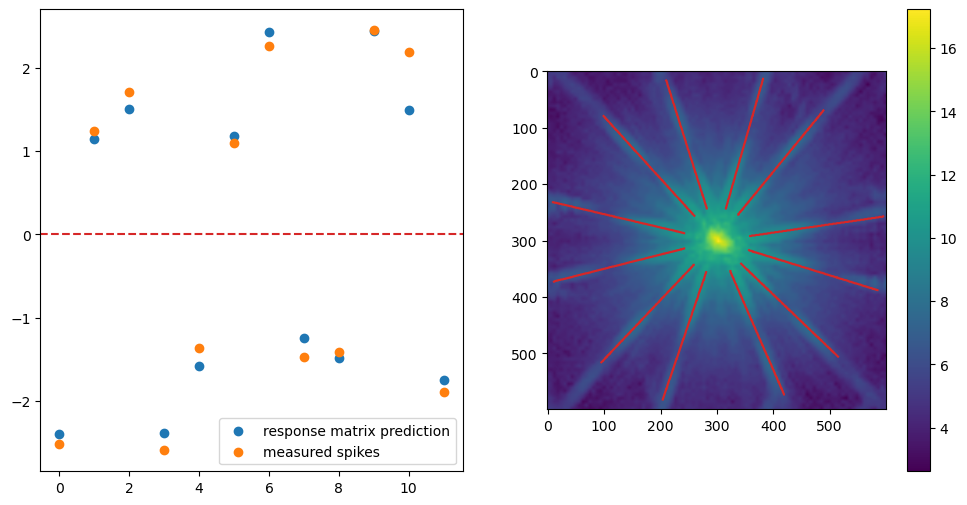

In [60]:
big_resp_matrix = np.zeros( ( 12, 5, 4 ) )
big_resp_matrix[ :, :, 0 ] = resp_matrix_04
big_resp_matrix[ :, :, 1 ] = resp_matrix_07
big_resp_matrix[ :, :, 2 ] = resp_matrix_10
big_resp_matrix[ :, :, 3 ] = resp_matrix_13
resp_matrix = np.mean( big_resp_matrix, axis=-1 )


predict_angle_diffs = resp_matrix @ np.array( test_aberrations )
spike_list_test = find_spikes( test_psf, step, dense_bound, dense_center, borders=borders )

dth_vec = spike_list_test - ideal_spikes
predict_aberrations = np.linalg.inv( resp_matrix.T @ resp_matrix ) @ resp_matrix.T @ dth_vec
N = np.arange( spike_list_test.size )

print( f'Generated aberrations: {test_aberrations}' )
print( f'Predicted from response matrix: {predict_aberrations}' )

fig, ax = plt.subplots( figsize=( 12, 6 ), ncols=2 )

ax[0].scatter( N, predict_angle_diffs, label='response matrix prediction' )
ax[0].scatter( N, dth_vec, label='measured spikes' )
ax[0].axhline( 0, color='C3', ls='--' )
ax[0].legend( )

im = ax[1].imshow( test_psf )
fig.colorbar( im, ax=ax[1] )

# with np.printoptions( precision=4, floatmode='fixed' ):
#     ax[1].set_title( f'{test_aberrations}' )

for s in spike_list_test:
    draw_ray( ax[1], s, dense_bound, dense_center, borders=borders, color='C3' )

Some stats about how good the response matrix estimation of the zernikes is

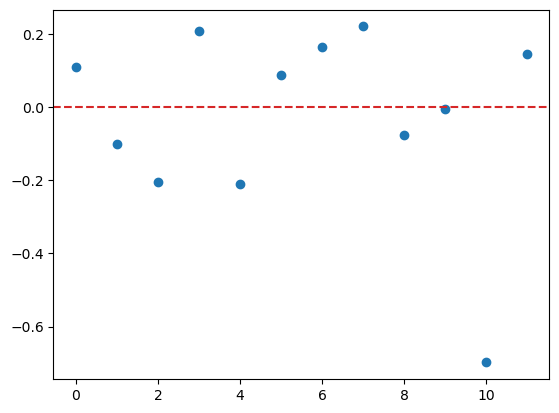

In [61]:
plt.scatter( N, predict_angle_diffs - dth_vec )
plt.axhline( 0, color='C3', ls='--' )

In [48]:
n = 15
N = np.full( ( 15, 12 ), np.arange( 12 )[ np.newaxis, : ] )
print( N )

[[ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 0  1  2  3  4  5  6  7  8  9 10 11]]


In [49]:
n = 15
aberration_arr = np.linspace( 0.01, 0.15, n )
dth_mat = np.zeros( ( 15, 12 ) )
for i in np.arange( n ):
    j129_obj.compute_poly_psf(
        optical_psf_only=True, use_postage_stamp_size = 96, ovsamp=ovsamp,
        use_filter='J129', extra_aberrations=( aberration_arr[i], )
    )
    psf = np.log10( poisson_resample_image(
        downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
        flux_factor
    ) )
    spikes = find_spikes( psf, step, bound, center, borders=borders )
    dth_mat[i] = spikes - ideal_spikes

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm
Cutoff of 109.053
9.30, 9.40 and 15.50, 15.60. interpolated as 9.38, 15.57
47.50, 47.60 and 54.60, 54.70. interpolated as 47.54, 54.62
70.50, 70.60 and 77.10, 77.20. interpolated as 70.52, 77.17
107.90, 108.00 and 116.80, 116.90. interpolated as 107.95, 116.84
128.90, 129.00 and 140.80, 140.90. interpolated as 128.94, 140.84
160.50, 160.60 and 168.40, 168.50. interpolated as 160.56, 168.47
187.40, 187.50 and 194.80, 194.90. interpolated as 187.48, 194.85
222.30, 222.40 and 229.90, 230.00. interpolated as 222.36, 229.92
245.90, 246.00 and 253.30, 253.40. interpolated as 245.93, 253.37
286.60, 286.70 and 293.80, 293.90. interpolated as 286.61, 293.89
310.00, 310.10 and 316.60, 316.70. interpolated as 310.02, 316.69
341.50, 341.60 and 347.80, 347.90. interpolated as 341.50, 347.86


[[ 1.48830067  1.04019416  0.61135758  1.3418827  -0.07718329 -1.36521793
  -0.56190212 -1.19507785 -1.6311497  -0.13321834 -0.05881622  0.08289842]
 [ 1.4907234   1.09962705  0.62765896  1.4570635   0.17714608 -1.3684672
  -0.54537749 -1.27157843 -1.6836712  -0.21577865 -0.10853562  0.10447421]
 [ 1.61381113  1.14896924  0.74032312  1.49163141 -0.13788092 -1.29741009
  -0.46974307 -1.29210016 -1.81216391 -0.13171289 -0.16878591  0.07575968]
 [ 1.56656963  1.16808637  0.83428301  1.49020136  0.12478235 -1.30517787
  -0.50036895 -1.39119056 -2.06360097 -0.24663431 -0.16757641  0.06401883]
 [ 1.60376698  1.18100893  0.84355779  1.6237394   0.32082282 -1.2905515
  -0.55041541 -1.42785056 -2.25722038 -0.25282642 -0.1964683   0.0841976 ]
 [ 1.51503934  1.23590612  0.87070457  1.59796223  0.16128347 -1.33428065
  -0.50812874 -1.44036748 -2.03739536 -0.42273386 -0.31015142  0.1566044 ]
 [ 1.54018939  1.24236743  0.94445635  1.76321148  0.19742398 -1.2101078
  -0.51585812 -1.49137196 -2.380879

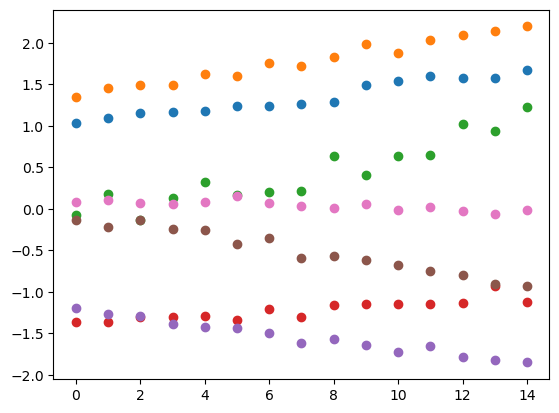

In [50]:
print( dth_mat )

fig, ax = plt.subplots( )

spike_count = 12

a = np.arange( n )
ax.scatter( a, dth_mat[ :, 1 ] )
ax.scatter( a, dth_mat[ :, 3 ] )
ax.scatter( a, dth_mat[ :, 4 ] )
ax.scatter( a, dth_mat[ :, 5 ] )
ax.scatter( a, dth_mat[ :, 7 ] )
ax.scatter( a, dth_mat[ :, 9 ] )
ax.scatter( a, dth_mat[ :, 11 ] )

# for i in np.arange( n )[:4]:
#     ax.scatter( np.arange( spike_count ), dth_mat[i] )

In [51]:
n = 15
aberration_arr = np.linspace( 0.01, 0.15, n )
dth_mat_vcenter = np.zeros( ( 15, 12 ) )
for i in np.arange( n ):
    j129_obj.compute_poly_psf(
        optical_psf_only=True, use_postage_stamp_size = 96, ovsamp=ovsamp,
        use_filter='J129', extra_aberrations=( None, aberration_arr[i], )
    )
    psf = np.log10( poisson_resample_image(
        downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
        flux_factor
    ) )
    spikes = find_spikes( psf, step, bound, center, borders=borders )
    dth_mat_vcenter[i] = spikes - ideal_spikes

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm
Cutoff of 108.733
8.00, 8.10 and 14.40, 14.50. interpolated as 8.03, 14.47
46.10, 46.20 and 53.10, 53.20. interpolated as 46.19, 53.20
69.00, 69.10 and 75.80, 75.90. interpolated as 69.04, 75.90
107.50, 107.60 and 116.00, 116.10. interpolated as 107.51, 116.09
130.30, 130.40 and 138.50, 138.60. interpolated as 130.33, 138.52
161.40, 161.50 and 169.00, 169.10. interpolated as 161.49, 169.02
188.80, 188.90 and 195.80, 195.90. interpolated as 188.90, 195.87
223.30, 223.40 and 231.30, 231.40. interpolated as 223.37, 231.39
246.90, 247.00 and 254.80, 254.90. interpolated as 246.94, 254.80
286.80, 286.90 and 295.00, 295.10. interpolated as 286.82, 295.06
309.70, 309.80 and 317.00, 317.10. interpolated as 309.73, 317.02
340.50, 340.60 and 347.30, 347.40. interpolated as 340.53, 347.36


[[ 1.45655911e+00  9.93664168e-01  4.90323200e-01  1.32540819e+00
  -6.50447360e-01 -1.29406413e+00 -4.32223935e-01 -1.16340149e+00
  -1.68381029e+00 -3.43107865e-02 -1.19546739e-01  1.09073037e-01]
 [ 1.31026755e+00  1.00488603e+00  4.83989224e-01  1.28732451e+00
  -3.49523211e-02 -1.13030692e+00 -3.27778152e-01 -1.16030741e+00
  -1.67801770e+00 -6.45302044e-02 -1.26166189e-01 -6.92139248e-03]
 [ 1.22856358e+00  9.56863010e-01  4.33684191e-01  1.38892125e+00
   1.39450239e-01 -1.14230496e+00 -2.03865694e-01 -9.67224395e-01
  -1.88080580e+00 -3.62597656e-02 -1.49102080e-01 -2.37056406e-02]
 [ 1.22178725e+00  8.38763622e-01  3.90942435e-01  1.36567663e+00
  -4.09162217e-01 -9.09642965e-01 -1.98920149e-01 -9.60942010e-01
  -1.47366097e+00 -4.86961750e-02 -1.55960770e-01 -3.73028616e-02]
 [ 1.17061652e+00  7.21466388e-01  4.48862260e-01  1.43115555e+00
   1.80766287e-01 -8.87823744e-01 -8.65002904e-02 -9.49657903e-01
  -1.63557778e+00 -5.61882344e-02 -1.81830127e-01 -1.11215548e-01]
 [ 1.

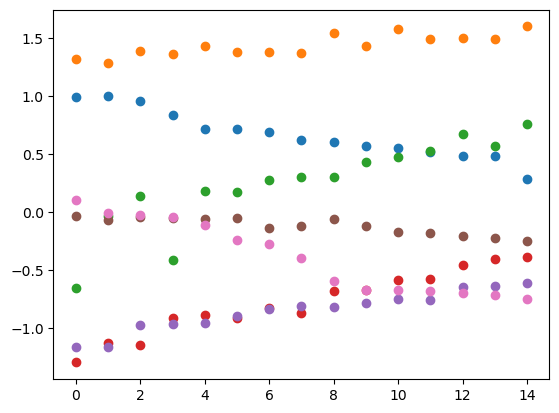

In [52]:
print( dth_mat_vcenter )

fig, ax = plt.subplots( )

spike_count = 12

a = np.arange( n )
ax.scatter( a, dth_mat_vcenter[ :, 1 ] )
ax.scatter( a, dth_mat_vcenter[ :, 3 ] )
ax.scatter( a, dth_mat_vcenter[ :, 4 ] )
ax.scatter( a, dth_mat_vcenter[ :, 5 ] )
ax.scatter( a, dth_mat_vcenter[ :, 7 ] )
ax.scatter( a, dth_mat_vcenter[ :, 9 ] )
ax.scatter( a, dth_mat_vcenter[ :, 11 ] )

In [53]:
n = 15
aberration_arr = np.linspace( 0.01, 0.15, n )
dth_mat_focus = np.zeros( ( 15, 12 ) )
for i in np.arange( n ):
    j129_obj.compute_poly_psf(
        optical_psf_only=True, use_postage_stamp_size = 96, ovsamp=ovsamp,
        use_filter='J129', extra_aberrations=( None, None, aberration_arr[i], )
    )
    psf = np.log10( poisson_resample_image(
        downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
        flux_factor
    ) )
    spikes = find_spikes( psf, step, bound, center, borders=borders )
    dth_mat_focus[i] = spikes - ideal_spikes

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm
Cutoff of 109.624
7.10, 7.20 and 13.40, 13.50. interpolated as 7.19, 13.43
48.50, 48.60 and 55.40, 55.50. interpolated as 48.58, 55.46
71.40, 71.50 and 78.80, 78.90. interpolated as 71.49, 78.86
105.60, 105.70 and 113.50, 113.60. interpolated as 105.65, 113.52
125.90, 126.00 and 135.70, 135.80. interpolated as 125.94, 135.73
163.00, 163.10 and 170.40, 170.50. interpolated as 163.02, 170.46
190.20, 190.30 and 196.60, 196.70. interpolated as 190.30, 196.67
221.40, 221.50 and 228.50, 228.60. interpolated as 221.47, 228.53
245.50, 245.60 and 252.40, 252.50. interpolated as 245.54, 252.46
289.00, 289.10 and 296.70, 296.80. interpolated as 289.07, 296.76
312.40, 312.50 and 319.80, 319.90. interpolated as 312.47, 319.81
338.40, 338.50 and 345.80, 345.90. interpolated as 338.47, 345.83


[[ 1.41175016  1.1363417   0.65832297  1.07560989 -1.0215486  -1.31550305
  -0.33638914 -1.28715105 -1.79970314  0.10805521  0.02605272 -0.0066131 ]
 [ 1.25157698  1.19487435  0.85782322  1.09754624 -1.11097159 -0.90892085
  -0.11862491 -1.42517179 -1.94981581  0.15050931  0.29511766 -0.09729671]
 [ 1.10908376  1.2639956   0.92685967  0.96726329 -1.16791601 -0.76123489
  -0.04838578 -1.56401132 -2.17194148  0.33326273  0.37670766 -0.24524984]
 [ 0.93386981  1.41250873  1.06186966  0.81048027 -1.31225559 -0.69053771
   0.05417174 -1.71315345 -2.22838285  0.37992747  0.53754323 -0.48518965]
 [ 0.84704571  1.61246392  1.18461858  0.84062652 -1.69664305 -0.52110371
   0.25317934 -1.83111574 -2.46676723  0.50824568  0.64286177 -0.74541871]
 [ 0.66623266  1.65451745  1.42295858  0.59452419 -1.80036462 -0.2278171
   0.40586545 -1.88490072 -2.41939884  0.6411343   0.73609782 -0.8183227 ]
 [ 0.53896157  1.74465324  1.55121115  0.57281772 -1.89898931 -0.13097122
   0.55080062 -1.95403013 -2.6313

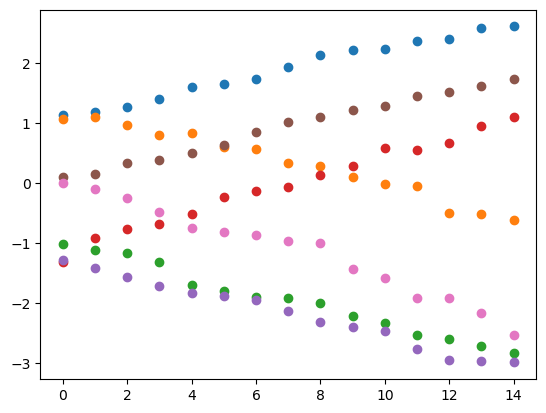

In [54]:
print( dth_mat_focus )

fig, ax = plt.subplots( )

spike_count = 12

a = np.arange( n )
ax.scatter( a, dth_mat_focus[ :, 1 ] )
ax.scatter( a, dth_mat_focus[ :, 3 ] )
ax.scatter( a, dth_mat_focus[ :, 4 ] )
ax.scatter( a, dth_mat_focus[ :, 5 ] )
ax.scatter( a, dth_mat_focus[ :, 7 ] )
ax.scatter( a, dth_mat_focus[ :, 9 ] )
ax.scatter( a, dth_mat_focus[ :, 11 ] )

In [55]:
n = 15
aberration_arr = np.linspace( 0.01, 0.15, n )
dth_mat_z5 = np.zeros( ( 15, 12 ) )
for i in np.arange( n ):
    j129_obj.compute_poly_psf(
        optical_psf_only=True, use_postage_stamp_size = 96, ovsamp=ovsamp,
        use_filter='J129', extra_aberrations=( None, None, None, aberration_arr[i], )
    )
    psf = np.log10( poisson_resample_image(
        downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
        flux_factor
    ) )
    spikes = find_spikes( psf, step, bound, center, borders=borders )
    dth_mat_z5[i] = spikes - ideal_spikes

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm
Cutoff of 109.153
10.00, 10.10 and 16.30, 16.40. interpolated as 10.07, 16.32
45.50, 45.60 and 53.10, 53.20. interpolated as 45.51, 53.12
68.80, 68.90 and 75.60, 75.70. interpolated as 68.89, 75.63
106.60, 106.70 and 115.30, 115.40. interpolated as 106.65, 115.33
126.30, 126.40 and 136.40, 136.50. interpolated as 126.39, 136.43
161.50, 161.60 and 169.00, 169.10. interpolated as 161.58, 169.09
186.90, 187.00 and 194.00, 194.10. interpolated as 186.93, 194.02
224.40, 224.50 and 232.00, 232.10. interpolated as 224.41, 232.02
247.70, 247.80 and 254.80, 254.90. interpolated as 247.75, 254.87
287.90, 288.00 and 295.30, 295.40. interpolated as 287.92, 295.39
311.80, 311.90 and 319.10, 319.20. interpolated as 311.87, 319.18
340.50, 340.60 and 346.90, 347.00. interpolated as 340.57, 346.94


[[ 1.56680425e+00  9.32154909e-01  4.91394092e-01  1.27161283e+00
  -7.72297654e-01 -1.34215454e+00 -6.16593537e-01 -1.14359730e+00
  -1.56573581e+00  6.60653843e-02  1.35809807e-02  4.01674026e-02]
 [ 1.71721008e+00  8.76981565e-01  3.92109158e-01  1.22233709e+00
  -9.98860677e-01 -1.30089637e+00 -7.26538281e-01 -9.59992612e-01
  -1.65582448e+00 -8.40883343e-02  1.34517172e-01 -9.51143964e-03]
 [ 1.67226271e+00  7.39045887e-01  3.81522817e-01  1.25631358e+00
  -1.08210107e+00 -1.07650124e+00 -7.50956373e-01 -8.84755967e-01
  -1.62553598e+00  3.92046922e-02  2.06260761e-01 -6.37392737e-02]
 [ 1.80613108e+00  5.77903619e-01  4.39264176e-01  1.07372216e+00
  -1.24615388e+00 -1.08575370e+00 -7.52429885e-01 -7.69411175e-01
  -1.64520600e+00  1.19773894e-01  3.90592016e-01 -1.03842276e-01]
 [ 1.82549443e+00  5.83161602e-01  3.80204971e-01  1.15674313e+00
  -1.16427563e+00 -9.22852105e-01 -8.51887264e-01 -6.59730142e-01
  -1.43609696e+00  1.04018590e-01  5.08911470e-01 -7.83176698e-02]
 [ 1.

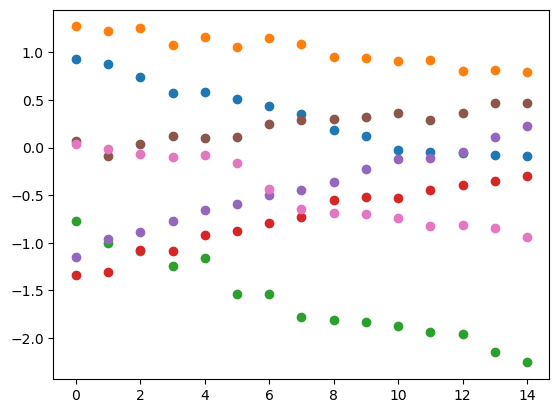

In [56]:
print( dth_mat_z5 )

fig, ax = plt.subplots( )

spike_count = 12

a = np.arange( n )
ax.scatter( a, dth_mat_z5[ :, 1 ] )
ax.scatter( a, dth_mat_z5[ :, 3 ] )
ax.scatter( a, dth_mat_z5[ :, 4 ] )
ax.scatter( a, dth_mat_z5[ :, 5 ] )
ax.scatter( a, dth_mat_z5[ :, 7 ] )
ax.scatter( a, dth_mat_z5[ :, 9 ] )
ax.scatter( a, dth_mat_z5[ :, 11 ] )

In [57]:
n = 15
aberration_arr = np.linspace( 0.01, 0.15, n )
dth_mat_z6 = np.zeros( ( 15, 12 ) )
for i in np.arange( n ):
    j129_obj.compute_poly_psf(
        optical_psf_only=True, use_postage_stamp_size = 96, ovsamp=ovsamp,
        use_filter='J129', extra_aberrations=( None, None, None, None, aberration_arr[i] )
    )
    psf = np.log10( poisson_resample_image(
        downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
        flux_factor
    ) )
    spikes = find_spikes( psf, step, bound, center, borders=borders )
    dth_mat_z6[i] = spikes - ideal_spikes

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm
Cutoff of 109.263
10.10, 10.20 and 17.00, 17.10. interpolated as 10.19, 17.01
46.70, 46.80 and 53.70, 53.80. interpolated as 46.76, 53.72
70.80, 70.90 and 77.80, 77.90. interpolated as 70.86, 77.89
106.10, 106.20 and 114.30, 114.40. interpolated as 106.16, 114.36
130.00, 130.10 and 137.80, 137.90. interpolated as 130.08, 137.82
157.70, 157.80 and 166.80, 166.90. interpolated as 157.78, 166.87
186.80, 186.90 and 193.70, 193.80. interpolated as 186.89, 193.71
223.00, 223.10 and 230.70, 230.80. interpolated as 223.01, 230.76
246.00, 246.10 and 253.00, 253.10. interpolated as 246.05, 253.07
288.40, 288.50 and 295.90, 296.00. interpolated as 288.43, 295.94
310.10, 310.20 and 317.50, 317.60. interpolated as 310.19, 317.50
342.70, 342.80 and 349.30, 349.40. interpolated as 342.75, 349.35


[[ 1.58240805  0.97692434  0.67261649  1.22705744  0.0763705  -1.45463736
  -0.64409064 -1.20556135 -1.7921204   0.05103544 -0.03107788  0.29461624]
 [ 1.68315852  1.03528012  0.75055469  1.24413269 -0.85129032 -1.40332953
  -0.66418962 -1.25758152 -2.02450138  0.12763154 -0.1062107   0.41668468]
 [ 1.79567672  1.05509881  0.85050141  1.18955183 -0.70081602 -1.53368607
  -0.73553026 -1.24367643 -2.26252687  0.21576042 -0.06198109  0.41388371]
 [ 1.78612523  1.01424855  0.89446344  0.98614183  0.04148748 -1.56266606
  -0.78730757 -1.19764329 -2.14279996  0.29613295 -0.0923448   0.52499028]
 [ 1.85002606  0.99489996  0.99180036  0.97667451  0.06723173 -1.59778866
  -0.86751647 -1.20983695 -2.16883928  0.26839796 -0.12910657  0.53037971]
 [ 1.95333164  0.99604438  1.06164321  0.92799188  0.14995105 -2.09994803
  -1.03088687 -1.2146804  -2.40678129  0.37116369 -0.10648743  0.67893124]
 [ 2.07820349  1.00732495  1.14730076  0.83788308 -0.11427981 -2.14660845
  -0.89195879 -1.21337764 -2.430

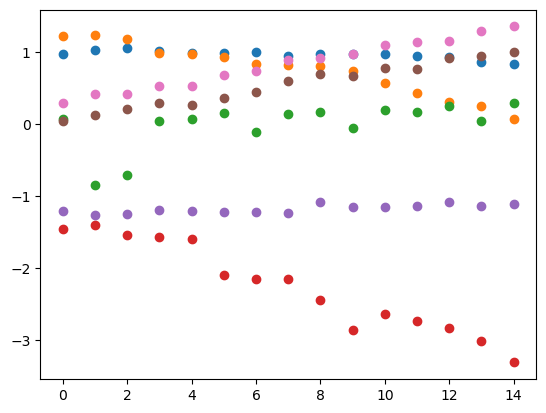

In [58]:
print( dth_mat_z6 )

fig, ax = plt.subplots( )

spike_count = 12

a = np.arange( n )
ax.scatter( a, dth_mat_z6[ :, 1 ] )
ax.scatter( a, dth_mat_z6[ :, 3 ] )
ax.scatter( a, dth_mat_z6[ :, 4 ] )
ax.scatter( a, dth_mat_z6[ :, 5 ] )
ax.scatter( a, dth_mat_z6[ :, 7 ] )
ax.scatter( a, dth_mat_z6[ :, 9 ] )
ax.scatter( a, dth_mat_z6[ :, 11 ] )